**Applytransfer learningusingpre-trainedconvolutionalneuralnetworksandanalyze
itseffectivenessonacustomimageclassificationtask**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from google.colab import files
import os

In [3]:
print("Upload my dataset zip file:")
uploaded = files.upload()

Upload your dataset zip file:


Saving archive (2).zip to archive (2).zip


In [4]:
zip_file = list(uploaded.keys())[0]

In [5]:
!unzip -q "{zip_file}" -d dataset
print("Dataset unzipped successfully!")

Dataset unzipped successfully!


In [7]:
print("Dataset folders:")
print(os.listdir('dataset'))

Dataset folders:
['Pistachio_Image_Dataset']


In [10]:
data_dir = 'dataset'

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 20% for validation
)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)
val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1719 images belonging to 1 classes.
Found 429 images belonging to 1 classes.


In [11]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [12]:
#print("Train folders:", os.listdir('dataset/train'))
#print("Validation folders:", os.listdir('dataset/validation'))

In [13]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 332ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


In [16]:
loss, acc = model.evaluate(val_generator)
print(f"\nValidation Accuracy: {acc*100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 1.0000 - loss: 0.0000e+00

Validation Accuracy: 100.00%


In [18]:
print("Upload a test image:")
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

Upload a test image:


Saving kirmizi (1).jpg to kirmizi (1).jpg


In [23]:
from tensorflow.keras.preprocessing import image
import numpy as np

In [24]:
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


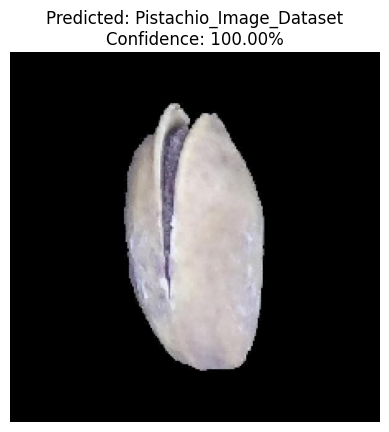

Prediction Complete!


In [26]:
import matplotlib.pyplot as plt

# Make predictions
predictions = model.predict(img_array)

# Get class labels
class_indices = train_generator.class_indices
class_labels = list(class_indices.keys())

predicted_class = class_labels[np.argmax(predictions)]
confidence = np.max(predictions) * 100

# Show image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.axis("off")
plt.show()

print("Prediction Complete!")